In [8]:
%load_ext autoreload
%autoreload 2
from utils import *
from jax.example_libraries import stax
from numpyro import optim
from CustomModules.architectures import *
from CustomModules.normalizing_flow import normalizing_flow
from sklearn.datasets import fetch_openml
import sklearn

import pickle
import os

import jax
import jax.numpy as jnp

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Jax psuedo random keys


In [2]:

# For reproducibility, we define a deterministic hashing function for our random keys
# Each unique string will correspond to a unique random independent key, but the same string will always yield the same key.
key_for = make_key_for(jax.random.key(1))

E0529 16:24:06.473843   82069 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)
E0529 16:24:06.482472   81928 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)


# Data

In [6]:

mnist = fetch_openml("mnist_784")
mnist_data = np.array(mnist.data) / 255.0
mnist_targets = np.array(mnist.target).astype(int)

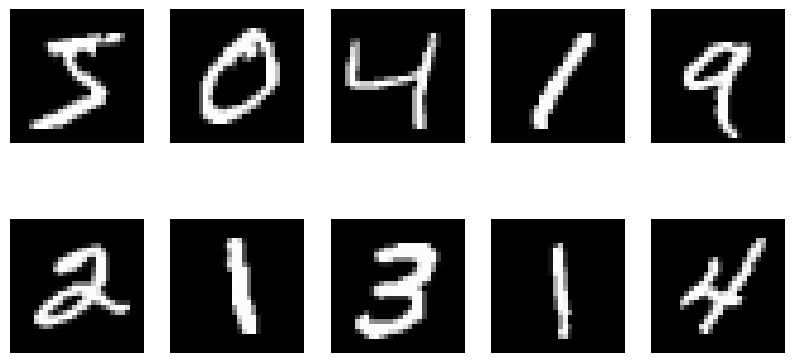

In [7]:
plot_images(mnist_data[:10], shape=(28, 28))

In [ ]:
diff = mnist_data.max() - mnist_data.min()

# squish the data to be between 0 and 1
mnist_data = (mnist_data - mnist_data.min()) / diff if mnist_data.max() != mnist_data.min() else mnist_data

X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(mnist_data, mnist_targets, test_size=0.2, random_state=42)



# Binarize by sampling from it as a distrubution
X_train = np.random.binomial(1, X_train)



X_test = np.random.binomial(1, X_test)


batch_size = 128

dataloader = [X_train[i:i+batch_size] for i in range(0, len(X_train), batch_size)]

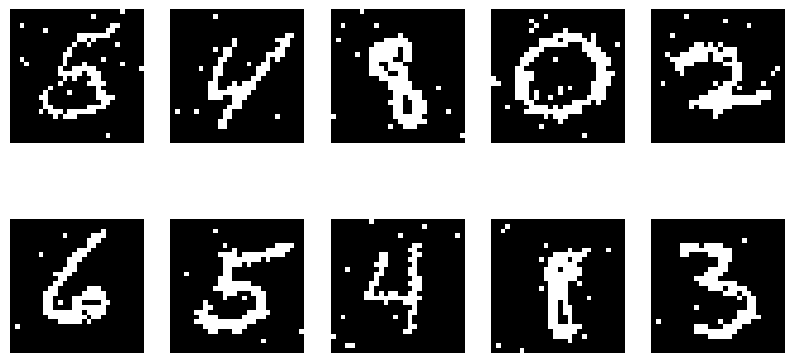

In [19]:
plot_images(X_train[:10], shape=(28, 28))